# Data_Evaluation

## Classification

In [8]:
import sklearn.metrics as metrics

In [9]:
y_pred = [1, 0, 0, 1, 0]
y_true = [1, 0, 1, 1, 0]

acc = metrics.accuracy_score(y_true, y_pred)
print(acc)

0.8


#### Recall

In [10]:
y_pred = [1, 0, 0, 1, 0, 1, 2, 1, 2]
y_true = [1, 0, 1, 1, 0, 0, 1, 2, 2]

recall = metrics.recall_score(y_true, y_pred,average = "macro")
print(
    metrics.recall_score(y_true, y_pred,average = "macro"),
    metrics.recall_score(y_true, y_pred,average = "micro"),
    metrics.recall_score(y_true, y_pred,average = "weighted"),
    metrics.recall_score(y_true, y_pred,average = None),
    # metrics.recall_score(y_true, y_pred,average = "binary")
)

0.5555555555555555 0.5555555555555556 0.5555555555555556 [0.66666667 0.5        0.5       ]


#### f1_score

In [11]:
metrics.f1_score(
    y_true,
    y_pred,
    average = "macro"
)

0.5555555555555555

#### confusion_matrix

In [12]:
y_true = [0, 0, 0, 1, 1, 1]
y_pred = [0, 0, 1, 0, 1, 1]

tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 2
FP: 1
FN: 1
TP: 2


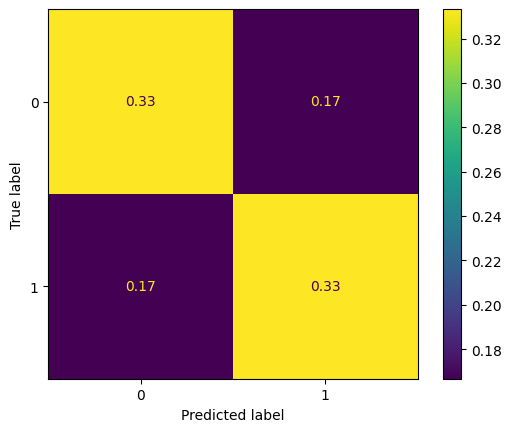

In [13]:
metrics.confusion_matrix(
    y_true = y_true,
    y_pred = y_pred,
    labels = [2,0]
)

metrics.ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    normalize = "all"
)

#### classification_report

In [14]:
print(metrics.classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.67      0.67      0.67         3

    accuracy                           0.67         6
   macro avg       0.67      0.67      0.67         6
weighted avg       0.67      0.67      0.67         6



### Probability Indicators

In [15]:
import sklearn.datasets as datasets
import sklearn.model_selection as model_selection
import sklearn.preprocessing as preprocessing
import sklearn.linear_model as linear_model
import sklearn.metrics as metrics
import sklearn.pipeline as pipeline

X, y = datasets.load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

pipe = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("model", linear_model.LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train, y_train)

y_proba = pipe.predict_proba(X_test)
print(pipe.classes_, y_proba[:5], sep = "\n-----\n")

[0 1]
-----
[[3.10179769e-02 9.68982023e-01]
 [9.99647982e-01 3.52018216e-04]
 [4.40588468e-01 5.59411532e-01]
 [6.10542466e-02 9.38945753e-01]
 [8.24508132e-01 1.75491868e-01]]


In [16]:
fpr, tpr, thres = metrics.roc_curve(y_test, y_proba[:,1])
print("fpr: ", fpr)
print("tpr: ", tpr)
print("thres: ", thres)

fpr:  [0.         0.         0.         0.01886792 0.01886792 1.        ]
tpr:  [0.         0.01111111 0.87777778 0.87777778 1.         1.        ]
thres:  [           inf 9.99999403e-01 9.00281691e-01 8.92930774e-01
 3.83064095e-01 5.31086312e-23]


#### ROC_Curve_Display

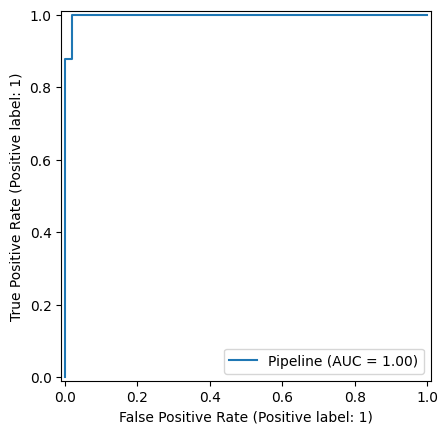

In [17]:
import matplotlib.pyplot as plt

metrics.RocCurveDisplay.from_estimator(
    pipe,
    X_test,
    y_test,
    pos_label=1,
)
plt.show()
plt.close()

## Regression

## Learning Curve

In [18]:
import numpy as np
import sklearn.datasets as datasets
import sklearn.svm as svm
import matplotlib.pyplot as plt

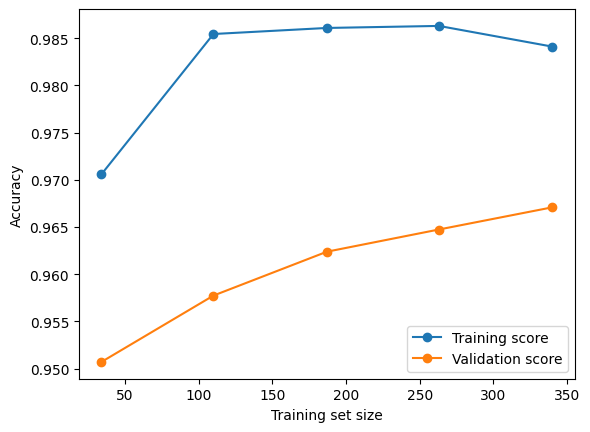

In [19]:
X, y = datasets.load_breast_cancer(return_X_y=True)

# 先保留最终测试集
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

pipe = pipeline.Pipeline([
    ("scaler", preprocessing.StandardScaler()),
    ("model", svm.SVC(kernel="rbf", C=1, gamma="scale"))
])

train_sizes, train_scores, val_scores = model_selection.learning_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.plot(train_sizes, train_mean, marker="o", label="Training score")
plt.plot(train_sizes, val_mean, marker="o", label="Validation score")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

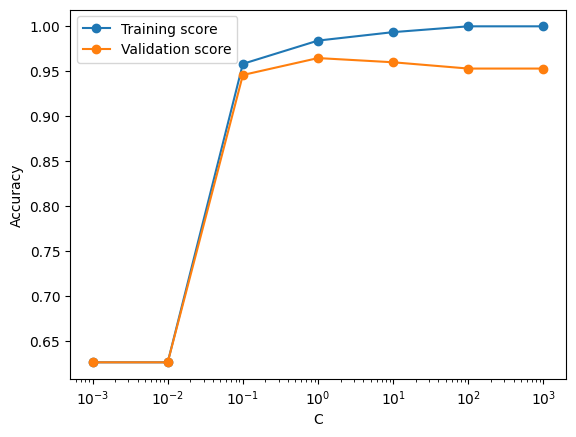

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", gamma="scale"))
])

param_range = np.logspace(-3, 3, 7)

train_scores, val_scores = validation_curve(
    estimator=pipe,
    X=X_train,
    y=y_train,
    param_name="model__C",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.semilogx(param_range, train_mean, marker="o", label="Training score")
plt.semilogx(param_range, val_mean, marker="o", label="Validation score")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.legend()
plt.show()